In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
exp_density = {280: 0.99987, 290: 0.99877, 300: 0.99657, 310: 0.99342, 320: 0.98945, 330: 0.98479}

In [7]:
# mace_small_280 = pd.read_csv('output/wat_mace_small/wat_280_npt_density.csv')

temperatures = [280, 290, 300, 310, 320, 330]
final_part_size = 0.5

grace_2l_small = dict()
grace_2l_small_dens = dict()
grace_2l_small_mean = dict()
for temp in temperatures:
    path = f'output/2l_wat_grace_small_b_off/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        grace_2l_small[temp] = pd.read_csv(path)
        grace_2l_small_dens[temp] = grace_2l_small[temp]['density_g_cm3']
        grace_2l_small_mean[temp] = grace_2l_small[temp][int(len(grace_2l_small[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        grace_2l_small[temp] = None
        grace_2l_small_dens[temp] = None
        grace_2l_small_mean[temp] = None



grace_2l_medium = dict()
grace_2l_medium_dens = dict()
grace_2l_medium_mean = dict()
for temp in temperatures:
    path = f'output/2l_wat_grace_medium_b_off/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        grace_2l_medium[temp] = pd.read_csv(path)
        grace_2l_medium_dens[temp] = grace_2l_medium[temp]['density_g_cm3']
        grace_2l_medium_mean[temp] = grace_2l_medium[temp][int(len(grace_2l_medium[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        grace_2l_medium[temp] = None
        grace_2l_medium_dens[temp] = None
        grace_2l_medium_mean[temp] = None


mace_small = dict()
mace_small_dens = dict()
mace_small_mean = dict()
for temp in temperatures:
    path = f'output/wat_mace_small/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        mace_small[temp] = pd.read_csv(path)
        mace_small_dens[temp] = mace_small[temp]['density_g_cm3']
        mace_small_mean[temp] = mace_small[temp][int(len(mace_small[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        mace_small[temp] = None
        mace_small_dens[temp] = None
        mace_small_mean[temp] = None

mace_medium = dict()
mace_medium_dens = dict()
mace_medium_mean = dict()
for temp in temperatures:
    path = f'output/wat_mace_medium/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        mace_medium[temp] = pd.read_csv(path)
        mace_medium_dens[temp] = mace_medium[temp]['density_g_cm3']
        mace_medium_mean[temp] = mace_medium[temp][int(len(mace_medium[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        mace_medium[temp] = None
        mace_medium_dens[temp] = None
        mace_medium_mean[temp] = None

In [4]:

# Build a table from all mean dictionaries
df = pd.DataFrame({
    "Temperature_K": temperatures,
    "Experimental": [exp_density[t] for t in temperatures],
    "Grace_2L_small": [grace_2l_small_mean[t] for t in temperatures],
    "Grace_2L_medium": [grace_2l_medium_mean[t] for t in temperatures],
    "MACE_small": [mace_small_mean[t] for t in temperatures],
    "MACE_medium": [mace_medium_mean[t] for t in temperatures],
})

# Save to CSV
# df.to_csv("all_density_means.csv", index=False)




In [10]:
df = pd.read_csv("all_density_means.csv")

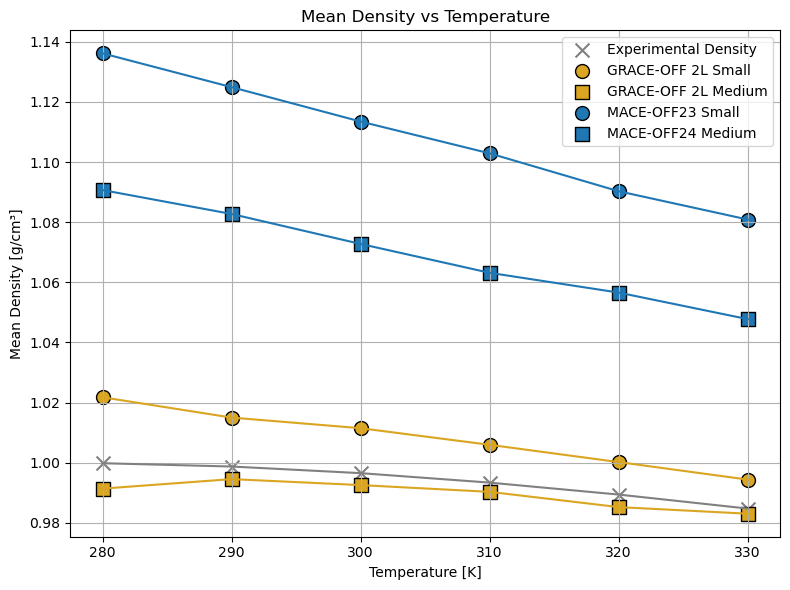

In [11]:
# --- Read the CSV ---
mean_data = pd.read_csv("all_density_means.csv")

# --- Define styles for each column (except Temperature) ---
plot_styles = {
    "Experimental": {"color": "gray", "marker": "x", "label": "Experimental Density"},
    "Grace_2L_small": {"color": "goldenrod", "marker": "o", "label": "GRACE-OFF 2L Small"},
    "Grace_2L_medium": {"color": "goldenrod", "marker": "s", "label": "GRACE-OFF 2L Medium"},
    "MACE_small": {"color": "tab:blue", "marker": "o", "label": "MACE-OFF23 Small"},
    "MACE_medium": {"color": "tab:blue", "marker": "s", "label": "MACE-OFF24 Medium"},
}

plt.figure(figsize=(8,6))

# --- Loop over columns to plot ---
for col, style in plot_styles.items():
    temps = mean_data["Temperature_K"]
    values = mean_data[col]
    
    plt.scatter(temps, values,
                color=style["color"],
                marker=style["marker"],
                edgecolor='k' if col != "Experimental" else None,
                s=100,
                label=style["label"])
    
    plt.plot(temps, values, color=style["color"])

# --- Final plot formatting ---
plt.xticks([280, 290, 300, 310, 320, 330])
plt.xlabel('Temperature [K]')
plt.ylabel('Mean Density [g/cm³]')
plt.title('Mean Density vs Temperature')
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.savefig('density_vs_temperature.png', dpi=300)
plt.show()


In [6]:
def get_data(model_type: str, size: str, temp: int) -> pd.DataFrame:
    path = f'output/{model_type}_wat_grace_{size}_b_off/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        return pd.read_csv(path)
    else:
        print(f"File not found: {path}")
        return None

grace = get_data('2l', 'medium', 310)
grace

File not found: output/2l_wat_grace_medium_b_off/wat_310_npt_density.csv


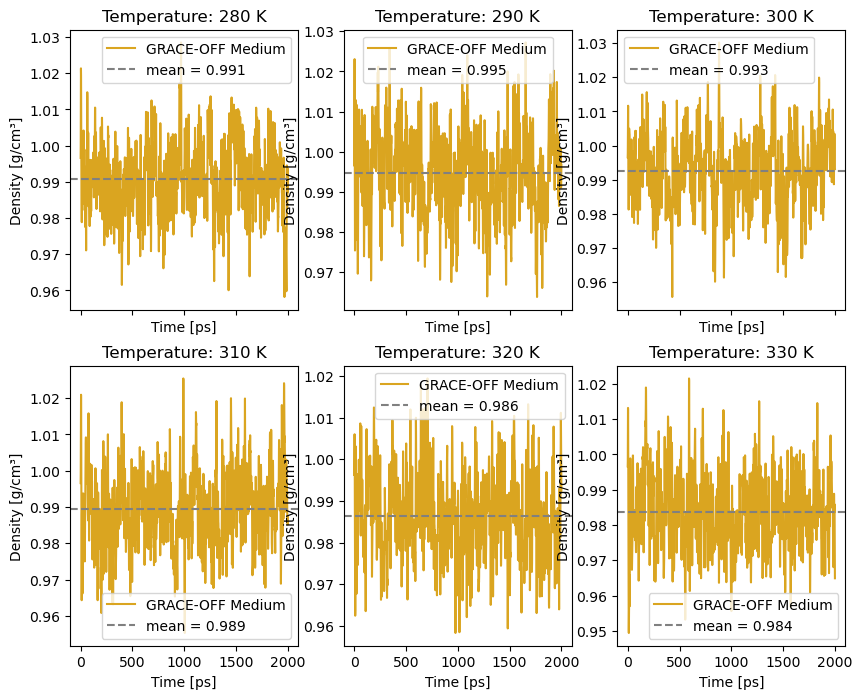

In [15]:
fig, axs = plt.subplots(2, 3, figsize=(10, 8), sharex=True)

axs = axs.flatten()

for i, temp in enumerate(temperatures):
    # Plot GRACE-OFF Medium
        if grace_2l_medium_dens[temp] is not None:
            axs[i].plot(grace_2l_medium_dens[temp],label='GRACE-OFF Medium', color='goldenrod')
            axs[i].axhline(y=grace_2l_medium_dens[temp].mean(),
                           label=f'mean = {grace_2l_medium_dens[temp].mean():.3f}', 
                           color='gray', 
                           linestyle='--')
            axs[i].set_title(f'Temperature: {temp} K')
            axs[i].set_xlabel('Time [ps]')
            axs[i].set_ylabel('Density [g/cm³]')
            axs[i].legend()

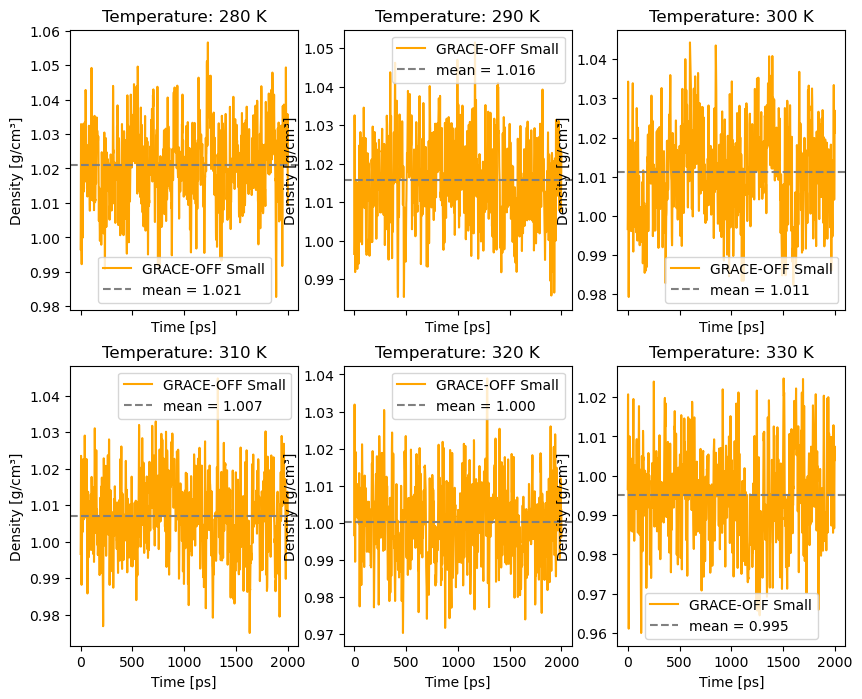

In [17]:
fig, axs = plt.subplots(2, 3, figsize=(10, 8), sharex=True)

axs = axs.flatten()

for i, temp in enumerate(temperatures):
    # Plot GRACE-OFF Medium
        if grace_2l_small_dens[temp] is not None:
            axs[i].plot(grace_2l_small_dens[temp],label='GRACE-OFF Small', color='orange')
            axs[i].axhline(y=grace_2l_small_dens[temp].mean(),
                           label=f'mean = {grace_2l_small_dens[temp].mean():.3f}', 
                           color='gray',
                           linestyle='--')
            axs[i].set_title(f'Temperature: {temp} K')
            axs[i].set_xlabel('Time [ps]')
            axs[i].set_ylabel('Density [g/cm³]')
            axs[i].legend()